<div style="text-align:center; font-size:40px; font-weight:700; margin-top:25px;">
Python pour Data Science - Projet - Groupe 4A
</div>

<br>

<div style="display:flex; justify-content:space-between; margin-top:35px; font-size:20px;">

  <div style="width:45%;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Étudiants :</div>
    <div>• Yassine MELLOUL</div>
    <div>• Amira BARHOUMI</div>
    <div>• Antoine FOUCART</div>
  </div>

  <div style="width:45%; text-align:right;">
    <div style="font-size:22px; font-weight:700; margin-bottom:10px;">Chargé de TD :</div>
    <div>Julien PRAMIL</div>
  </div>

</div>

<br>
<hr>

# **1-DESCRIPTION ET PROBLEMATIQUE**

# **2 -COLLECTE DE DONNEES ET NETTOYAGE**

# **3 -ANALYSE DESCRIPTIVE**

# **3 - ANALYSE DESCRIPTIVE**

Dans cette partie, nous explorons statistiquement les données immobilières nettoyées afin de :
- décrire les principales variables quantitatives ;
- étudier la répartition des variables qualitatives ;
- analyser les relations entre le prix, la surface et certaines catégories ;
- faire émerger les premiers constats utiles avant la modélisation.

L'objectif est d'identifier les facteurs les plus liés au prix immobilier, en particulier au **prix au m²**.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Pour pouvoir importer src/... depuis le dossier notebooks/
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data.collect import url_dvf, load__data_url_zip_txt
from src.data.clean import filter_dvf_columns, compute_prix_m2
from src.data.stats_desc import (
    numeric_summary,
    univariate_numeric_analysis,
    univariate_categorical_analysis,
    bivariate_numeric_numeric_analysis,
    bivariate_numeric_categorical_analysis,
    correlation_matrix,
    analyse_descriptive_complete,
)

In [16]:
# Si le DataFrame final existe déjà après la section 2, on le réutilise.
# Sinon, on recharge et on reconstruit un DataFrame propre.

if "df" not in globals():
    df_raw = load__data_url_zip_txt(url_dvf)
    df = filter_dvf_columns(df_raw)
    df = compute_prix_m2(df)

# Copie de travail
df_analysis = df.copy()

print("Shape du DataFrame d'analyse :", df_analysis.shape)
print("\nColonnes disponibles :")
print(df_analysis.columns.tolist())

display(df_analysis.head())

Shape du DataFrame d'analyse : (1111244, 9)

Colonnes disponibles :
['Valeur fonciere', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Type local', 'Surface reelle bati', 'Nature mutation', 'prix_m2']


,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nature mutation,prix_m2
2,468000.0,1550,FARGES,01,158,Maison,111.0,Vente,4216.216216
5,180000.0,1200,MONTANGES,01,257,Appartement,87.0,Vente,2068.965517
9,490000.0,1310,BUELLAS,01,65,Maison,190.0,Vente,2578.947368
14,490000.0,1310,BUELLAS,01,65,Maison,190.0,Vente,2578.947368
18,183000.0,1170,GEX,01,173,Appartement,35.0,Vente,5228.571429


In [17]:
print("Aperçu général")
print("-" * 50)
print("Nombre de lignes :", df_analysis.shape[0])
print("Nombre de colonnes :", df_analysis.shape[1])

print("\nTypes de variables :")
display(df_analysis.dtypes)

print("\nValeurs manquantes par colonne :")
display(df_analysis.isna().sum().sort_values(ascending=False))

print("\nStatistiques descriptives globales des variables numériques :")
display(df_analysis.describe(include="all").T)

Aperçu général
--------------------------------------------------
Nombre de lignes : 1111244
Nombre de colonnes : 9

Types de variables :


Valeur fonciere               float64
Code postal                    object
Commune                string[python]
Code departement       string[python]
Code commune           string[python]
Type local             string[python]
Surface reelle bati           float64
Nature mutation        string[python]
prix_m2                       float64
dtype: object


Valeurs manquantes par colonne :


Valeur fonciere        0
Code postal            0
Commune                0
Code departement       0
Code commune           0
Type local             0
Surface reelle bati    0
Nature mutation        0
prix_m2                0
dtype: int64


Statistiques descriptives globales des variables numériques :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Valeur fonciere,1111244.0,NaN,NaN,NaN,1033616.897875,9937383.380653,0.15,125000.0,202900.0,330000.0,695000000.0
Code postal,1111244,5856,89000,6123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commune,1111244,29074,TOULOUSE,9672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code departement,1111244,97,59,39755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code commune,1111244,905,88,11967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type local,1111244,2,Maison,614872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surface reelle bati,1111244.0,NaN,NaN,NaN,81.745044,45.802982,1.0,50.0,75.0,102.0,2044.0
Nature mutation,1111244,1,Vente,1111244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prix_m2,1111244.0,NaN,NaN,NaN,17925.095206,170986.593054,0.001379,1733.333333,2734.693878,4545.454545,31590909.090909


## 3.1 Analyse univariée des variables numériques

Nous analysons d'abord les principales variables quantitatives :
- la valeur foncière ;
- la surface réelle bâtie ;
- le prix au m².

Pour chacune, nous observons les tendances centrales, la dispersion et la présence éventuelle de valeurs extrêmes.


Analyse univariée numérique : Valeur fonciere
--------------------------------------------------
count      : 1111244
missing    : 0
mean       : 1,033,616.90
std        : 9,937,383.38
min        : 0.15
p05        : 50,914.50
q1         : 125,000.00
median     : 202,900.00
q3         : 330,000.00
p95        : 1,150,000.00
max        : 695,000,000.00
iqr        : 205,000.00
skew       : 26.89


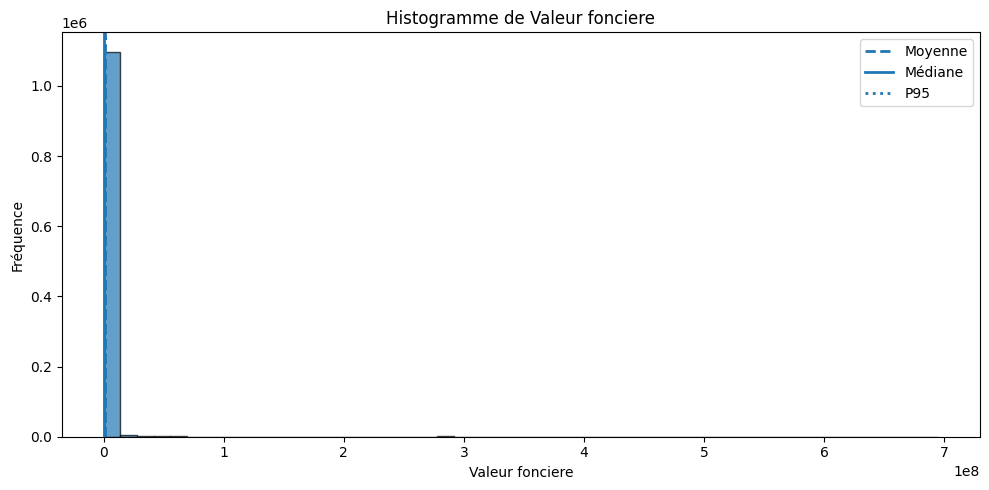


Analyse univariée numérique : Surface reelle bati
--------------------------------------------------
count      : 1111244
missing    : 0
mean       : 81.75
std        : 45.80
min        : 1.00
p05        : 24.00
q1         : 50.00
median     : 75.00
q3         : 102.00
p95        : 161.00
max        : 2,044.00
iqr        : 52.00
skew       : 2.28


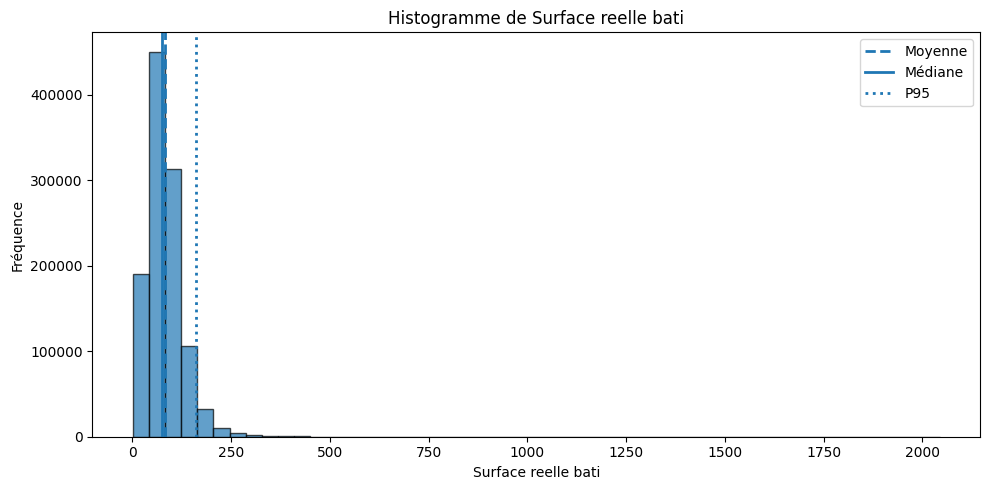


Analyse univariée numérique : prix_m2
--------------------------------------------------
count      : 1111244
missing    : 0
mean       : 17,925.10
std        : 170,986.59
min        : 0.00
p05        : 762.71
q1         : 1,733.33
median     : 2,734.69
q3         : 4,545.45
p95        : 18,622.45
max        : 31,590,909.09
iqr        : 2,812.12
skew       : 34.59


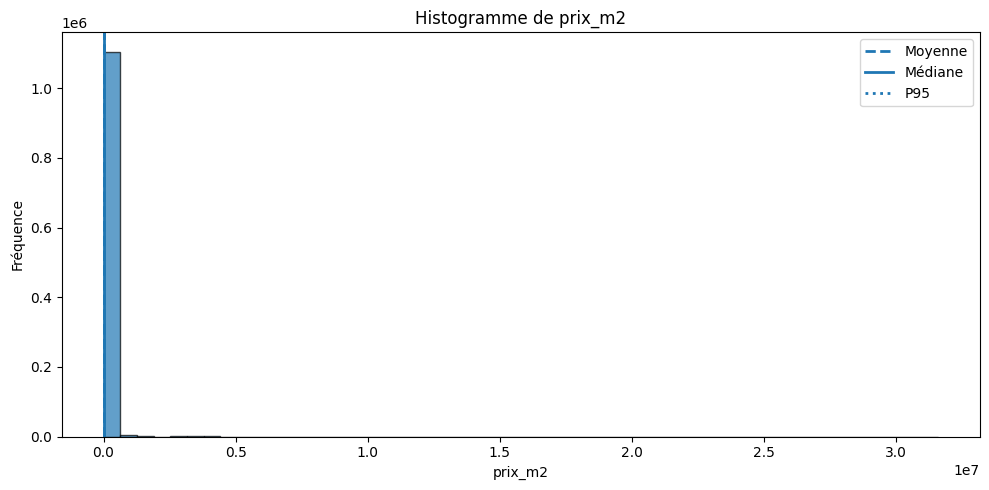

In [18]:
numeric_cols_to_study = [
    col for col in ["Valeur fonciere", "Surface reelle bati", "prix_m2"]
    if col in df_analysis.columns
]

numeric_results = {}

for col in numeric_cols_to_study:
    numeric_results[col] = univariate_numeric_analysis(
        df_analysis,
        col=col,
        bins=50,
        show_plot=True,
    )

In [6]:
resume_numerique = pd.DataFrame(numeric_results).T
display(resume_numerique.round(2))

,count,missing,mean,std,min,p05,q1,median,q3,p95,max,iqr,skew
Valeur fonciere,1111244.0,0.0,1033616.90,9937383.38,0.15,50914.50,125000.00,202900.00,330000.00,1150000.00,6.950000e+08,205000.00,26.89
Surface reelle bati,1111244.0,0.0,81.75,45.80,1.00,24.00,50.00,75.00,102.00,161.00,2.044000e+03,52.00,2.28
prix_m2,1111244.0,0.0,17925.10,170986.59,0.00,762.71,1733.33,2734.69,4545.45,18622.45,3.159091e+07,2812.12,34.59


## 3.2 Analyse univariée des variables qualitatives

Nous étudions ensuite la répartition des principales variables qualitatives afin de mieux comprendre la structure de l'échantillon :
- type de local ;
- département ;
- commune.


Analyse univariée catégorielle : Type local
--------------------------------------------------
      modalite  effectif  proportion_%
0       Maison    614872         55.33
1  Appartement    496372         44.67


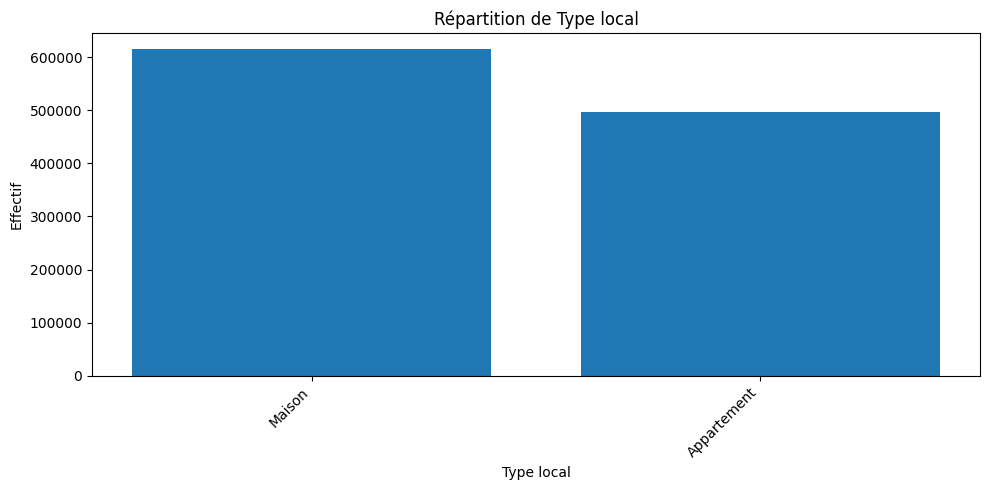


Analyse univariée catégorielle : Code departement
--------------------------------------------------
   modalite  effectif  proportion_%
0        59     39755          3.58
1        75     37220          3.35
2        33     35183          3.17
3        13     32782          2.95
4        06     30174          2.72
5        83     30049           2.7
6        69     27758           2.5
7        34     25030          2.25
8        31     24901          2.24
9        44     24671          2.22
10       76     23176          2.09
11       92     22144          1.99
12       93     20734          1.87
13       77     20632          1.86
14       62     19970           1.8


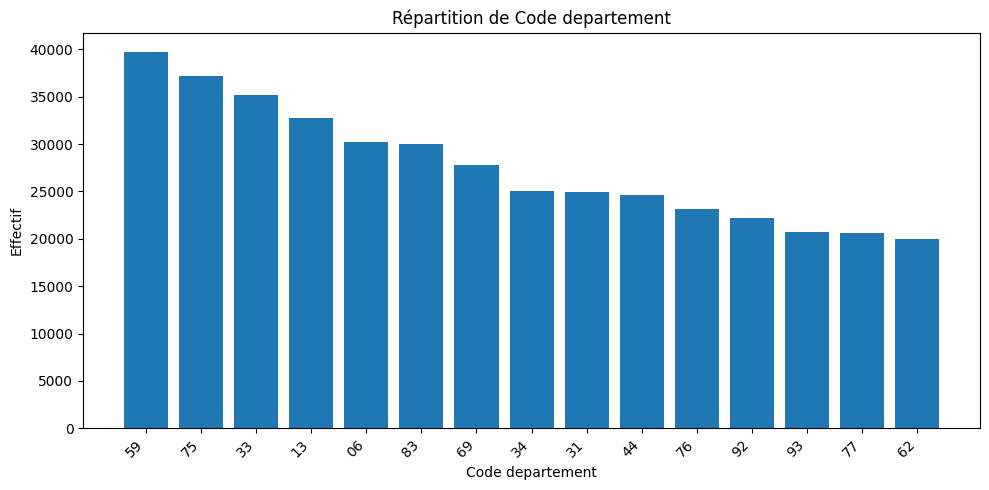


Analyse univariée catégorielle : Commune
--------------------------------------------------
               modalite  effectif  proportion_%
0              TOULOUSE      9672          0.87
1                  NICE      9262          0.83
2               AUXERRE      5984          0.54
3              BORDEAUX      5953          0.54
4                NANTES      5751          0.52
5           MONTPELLIER      5312          0.48
6   GRAYAN-ET-L HOPITAL      5279          0.48
7                 LILLE      4920          0.44
8              PARIS 18      3829          0.34
9              PARIS 15      3799          0.34
10        SAINT-ETIENNE      3767          0.34
11               TOULON      3697          0.33
12               RENNES      3599          0.32
13                BREST      3471          0.31
14                DIJON      3462          0.31


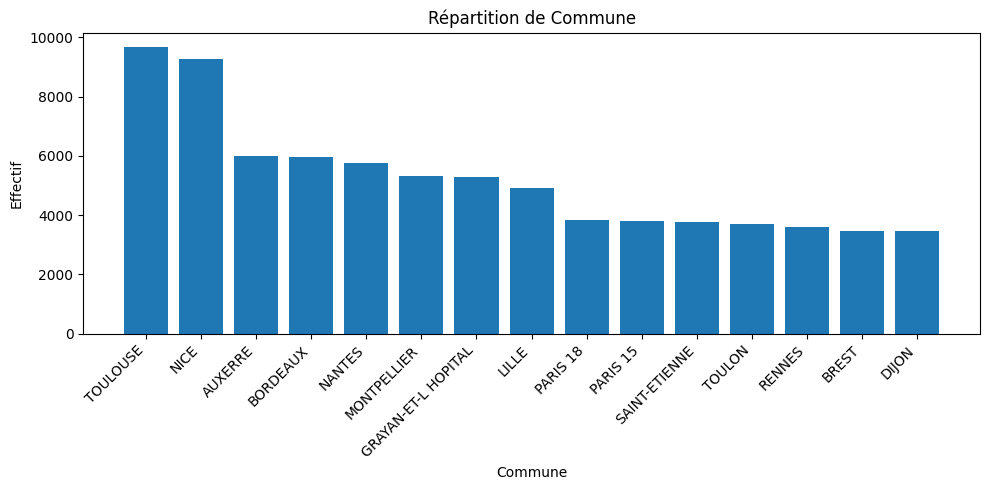

In [19]:
categorical_cols_to_study = [
    col for col in ["Type local", "Code departement", "Commune"]
    if col in df_analysis.columns
]

categorical_results = {}

for col in categorical_cols_to_study:
    top_n = 15 if col in ["Code departement", "Commune"] else 10
    categorical_results[col] = univariate_categorical_analysis(
        df_analysis,
        col=col,
        top_n=top_n,
        show_plot=True,
    )

In [20]:
if "Code departement" in df_analysis.columns:
    top_dep = df_analysis["Code departement"].value_counts().head(15).rename_axis("Code departement").reset_index(name="effectif")
    print("Top 15 départements les plus représentés")
    display(top_dep)

if "Commune" in df_analysis.columns:
    top_communes = df_analysis["Commune"].value_counts().head(15).rename_axis("Commune").reset_index(name="effectif")
    print("Top 15 communes les plus représentées")
    display(top_communes)

Top 15 départements les plus représentés


,Code departement,effectif
0,59,39755
1,75,37220
2,33,35183
3,13,32782
4,06,30174
5,83,30049
6,69,27758
7,34,25030
8,31,24901
9,44,24671


Top 15 communes les plus représentées


,Commune,effectif
0,TOULOUSE,9672
1,NICE,9262
2,AUXERRE,5984
3,BORDEAUX,5953
4,NANTES,5751
5,MONTPELLIER,5312
6,GRAYAN-ET-L HOPITAL,5279
7,LILLE,4920
8,PARIS 18,3829
9,PARIS 15,3799


## 3.3 Analyse bivariée entre variables numériques

Nous cherchons ici à mesurer le lien entre :
- la surface bâtie et la valeur foncière ;
- la surface bâtie et le prix au m².

Cela permet de distinguer ce qui relève d'un effet de taille et ce qui relève d'un effet de valorisation du bien.


Analyse bivariée numérique-numérique : Surface reelle bati ~ Valeur fonciere
--------------------------------------------------
Nombre d'observations : 1111244
Corrélation de Pearson : -0.0109


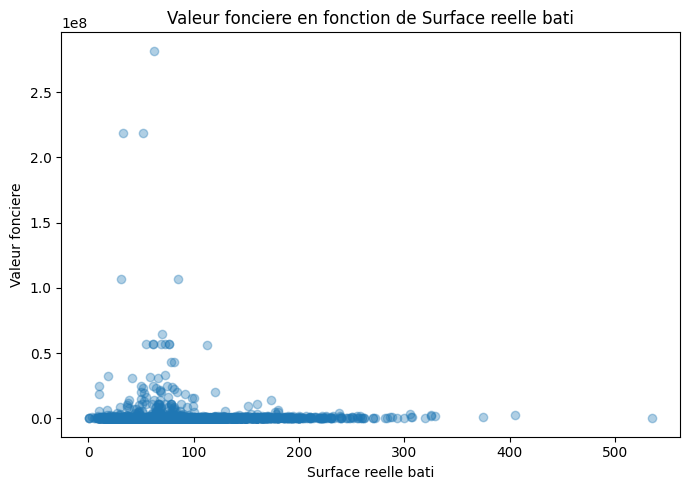


Analyse bivariée numérique-numérique : Surface reelle bati ~ prix_m2
--------------------------------------------------
Nombre d'observations : 1111244
Corrélation de Pearson : -0.0551


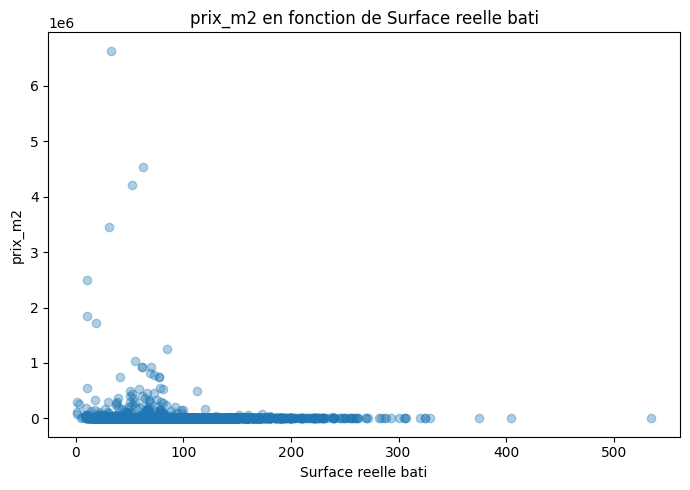

,n_obs,correlation_pearson,x_mean,y_mean
surface_vs_valeur,1111244.0,-0.0109,81.745,1.033617e+06
surface_vs_prix_m2,1111244.0,-0.0551,81.745,1.792510e+04


In [21]:
biv_num_num_results = {}

if {"Surface reelle bati", "Valeur fonciere"}.issubset(df_analysis.columns):
    biv_num_num_results["surface_vs_valeur"] = bivariate_numeric_numeric_analysis(
        df_analysis,
        x_col="Surface reelle bati",
        y_col="Valeur fonciere",
        sample_size=5000,
        show_plot=True,
    )

if {"Surface reelle bati", "prix_m2"}.issubset(df_analysis.columns):
    biv_num_num_results["surface_vs_prix_m2"] = bivariate_numeric_numeric_analysis(
        df_analysis,
        x_col="Surface reelle bati",
        y_col="prix_m2",
        sample_size=5000,
        show_plot=True,
    )

display(pd.DataFrame(biv_num_num_results).T.round(4))


Analyse bivariée numérique-catégorielle : prix_m2 ~ Type local
----------------------------------------------------------------------
             effectif   moyenne  mediane  ecart_type  minimum      maximum  \
Type local                                                                   
Maison         614872   5868.26  2208.97    83174.37      0.0  11267570.96   
Appartement    496372  32860.29  3782.96   237655.05      0.0  31590909.09   

                  q1       q3      iqr  
Type local                              
Maison       1466.67  3291.14  1824.47  
Appartement  2360.00  6908.74  4548.74  


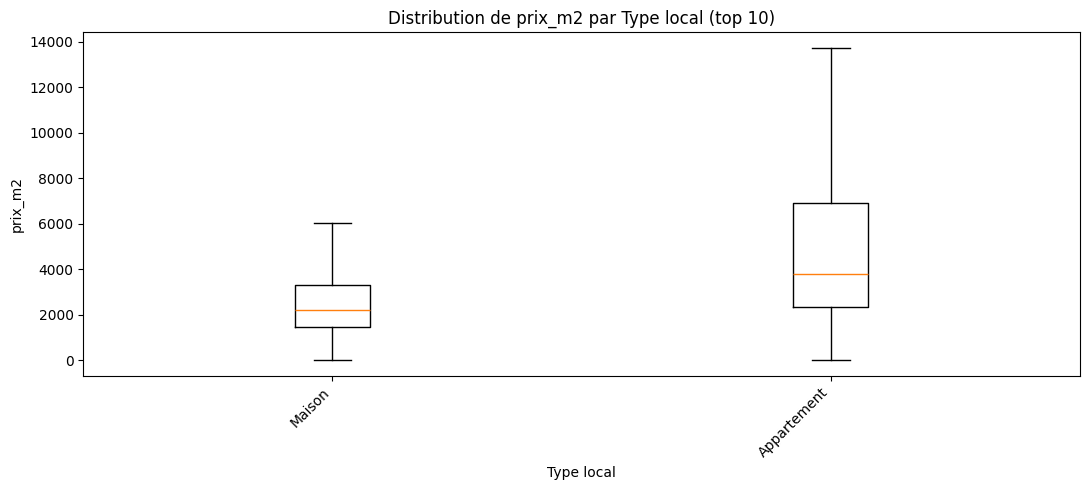

,Type local,effectif,moyenne,mediane,ecart_type,minimum,maximum,q1,q3,iqr
0,Maison,614872,5868.26,2208.97,83174.37,0.0,11267570.96,1466.67,3291.14,1824.47
1,Appartement,496372,32860.29,3782.96,237655.05,0.0,31590909.09,2360.00,6908.74,4548.74


In [22]:
if {"prix_m2", "Type local"}.issubset(df_analysis.columns):
    stats_prix_type = bivariate_numeric_categorical_analysis(
        df_analysis,
        num_col="prix_m2",
        cat_col="Type local",
        top_n=10,
        show_plot=True,
    )
    display(stats_prix_type.round(2))


Analyse bivariée numérique-catégorielle : prix_m2 ~ Code departement
----------------------------------------------------------------------
                  effectif   moyenne   mediane  ecart_type  minimum  \
Code departement                                                      
59                   39755   4457.37   2262.22    14315.68     0.00   
75                   37220  65202.54  10272.73   408911.50     0.00   
33                   35183  18434.69   3750.00   110734.44     0.00   
13                   32782   8807.04   3937.12    30365.20     0.01   
06                   30174  21599.44   5266.67    78675.32     0.00   
83                   30049   7342.73   4220.19    24129.79     0.00   
69                   27758   7268.25   3827.25    20539.17     0.00   
34                   25030   4190.21   3333.33     6700.11     0.01   
31                   24901  47787.95   2942.20   233457.18     0.01   
44                   24671   5056.68   3090.27    13836.61     0.01   

      

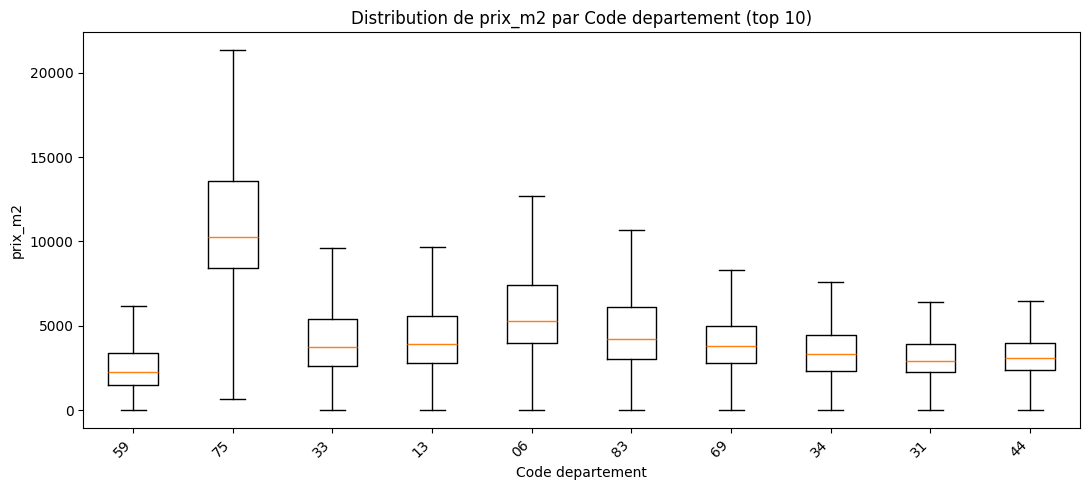

,Code departement,effectif,moyenne,mediane,ecart_type,minimum,maximum,q1,q3,iqr
0,59,39755,4457.37,2262.22,14315.68,0.00,391041.67,1516.72,3389.83,1873.11
1,75,37220,65202.54,10272.73,408911.50,0.00,31590909.09,8421.05,13586.96,5165.90
2,33,35183,18434.69,3750.00,110734.44,0.00,2205735.05,2625.00,5413.24,2788.24
3,13,32782,8807.04,3937.12,30365.20,0.01,1900000.00,2800.00,5558.09,2758.09
4,06,30174,21599.44,5266.67,78675.32,0.00,1607142.86,3962.43,7443.14,3480.71
...,...,...,...,...,...,...,...,...,...,...
92,2A,2517,6128.67,4451.79,8734.19,2.33,190000.00,3066.67,6260.78,3194.12
93,972,2401,14218.89,3253.73,36048.08,0.01,356671.91,1980.20,5887.10,3906.90
94,90,2376,2713.88,1666.67,4313.65,0.02,50766.67,1207.18,2411.17,1203.99
95,973,2210,22008.89,5875.02,48999.94,0.01,690732.62,2741.94,17766.67,15024.73


In [23]:
if {"prix_m2", "Code departement"}.issubset(df_analysis.columns):
    stats_prix_dep = bivariate_numeric_categorical_analysis(
        df_analysis,
        num_col="prix_m2",
        cat_col="Code departement",
        top_n=10,
        show_plot=True,
    )
    display(stats_prix_dep.round(2))

In [24]:
if {"prix_m2", "Code departement"}.issubset(df_analysis.columns):
    classement_dep = (
        df_analysis.groupby("Code departement")["prix_m2"]
        .agg(
            effectif="count",
            prix_m2_moyen="mean",
            prix_m2_median="median",
        )
        .sort_values("prix_m2_moyen", ascending=False)
    )

    # On peut filtrer pour éviter les départements avec trop peu d'observations
    classement_dep_filtre = classement_dep[classement_dep["effectif"] >= 30]

    print("Départements les plus chers en prix moyen au m² (effectif >= 30)")
    display(classement_dep_filtre.head(15).round(2))

    print("Départements les moins chers en prix moyen au m² (effectif >= 30)")
    display(classement_dep_filtre.tail(15).round(2))

Départements les plus chers en prix moyen au m² (effectif >= 30)


,effectif,prix_m2_moyen,prix_m2_median
Code departement,,,
66,13641,341932.37,2798.82
93,20734,140973.04,4908.89
75,37220,65202.54,10272.73
92,22144,47979.08,6929.72
31,24901,47787.95,2942.20
89,12022,44751.41,4065.59
95,14211,38900.98,3573.33
94,16419,24545.46,5175.00
973,2210,22008.89,5875.02


Départements les moins chers en prix moyen au m² (effectif >= 30)


,effectif,prix_m2_moyen,prix_m2_median
Code departement,,,
72,10717,2156.76,1690.14
81,5659,2156.55,1849.71
03,7386,2148.58,1391.46
02,8043,2112.34,1385.23
61,5651,2063.08,1446.75
19,5180,2036.20,1576.34
43,3693,2031.69,1634.62
18,6234,1977.07,1342.84
55,3237,1891.53,1250.00


## 3.5 Matrice de corrélation

Nous complétons l'analyse par une matrice de corrélation entre les principales variables numériques disponibles.


Matrice de corrélation
------------------------------
                     Valeur fonciere  Surface reelle bati  prix_m2
Valeur fonciere                1.000               -0.011    0.898
Surface reelle bati           -0.011                1.000   -0.055
prix_m2                        0.898               -0.055    1.000


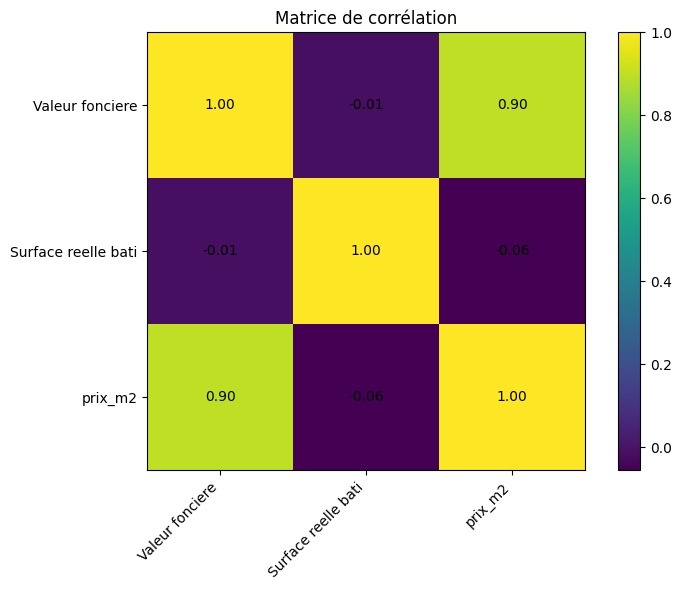

,Valeur fonciere,Surface reelle bati,prix_m2
Valeur fonciere,1.000,-0.011,0.898
Surface reelle bati,-0.011,1.000,-0.055
prix_m2,0.898,-0.055,1.000


In [25]:
corr_cols = [
    col for col in ["Valeur fonciere", "Surface reelle bati", "prix_m2"]
    if col in df_analysis.columns
]

if len(corr_cols) >= 2:
    corr_base = correlation_matrix(
        df_analysis,
        cols=corr_cols,
        method="pearson",
        show_plot=True,
    )
    display(corr_base.round(3))

In [14]:
optional_numeric_cols = [
    col for col in [
        "MED21",
        "TP6021",
        "P22_POP",
        "P22_CHOM1564",
        "P22_ACT1564",
        "taux_logements_sociaux",
    ]
    if col in df_analysis.columns
]

corr_extended_cols = ["prix_m2"] + optional_numeric_cols
corr_extended_cols = [col for col in corr_extended_cols if col in df_analysis.columns]

if len(corr_extended_cols) >= 2:
    print("Matrice de corrélation étendue (si variables socio-économiques disponibles)")
    corr_extended = correlation_matrix(
        df_analysis,
        cols=corr_extended_cols,
        method="pearson",
        show_plot=True,
    )
    display(corr_extended.round(3))
else:
    print("Pas assez de variables socio-économiques fusionnées pour une matrice étendue.")

Pas assez de variables socio-économiques fusionnées pour une matrice étendue.


## 3.6 Synthèse des principaux constats

Cette cellule génère automatiquement quelques indicateurs clés qui pourront être repris dans la rédaction du rapport.

In [26]:
print("=" * 80)
print("SYNTHESE AUTOMATIQUE")
print("=" * 80)

if "prix_m2" in df_analysis.columns:
    prix_stats = numeric_summary(df_analysis, "prix_m2")
    print(f"Prix moyen au m² : {prix_stats['mean']:.2f}")
    print(f"Prix médian au m² : {prix_stats['median']:.2f}")
    print(f"Écart-type du prix au m² : {prix_stats['std']:.2f}")
    print(f"95e percentile du prix au m² : {prix_stats['p95']:.2f}")
    print()

if "Surface reelle bati" in df_analysis.columns:
    surf_stats = numeric_summary(df_analysis, "Surface reelle bati")
    print(f"Surface moyenne : {surf_stats['mean']:.2f} m²")
    print(f"Surface médiane : {surf_stats['median']:.2f} m²")
    print()

if {"prix_m2", "Type local"}.issubset(df_analysis.columns):
    comparaison_type = (
        df_analysis.groupby("Type local")["prix_m2"]
        .agg(effectif="count", moyenne="mean", mediane="median")
        .sort_values("moyenne", ascending=False)
        .round(2)
    )
    print("Comparaison du prix au m² selon le type de local :")
    display(comparaison_type)

if {"prix_m2", "Code departement"}.issubset(df_analysis.columns):
    dep_resume = (
        df_analysis.groupby("Code departement")["prix_m2"]
        .agg(effectif="count", moyenne="mean")
        .query("effectif >= 30")
        .sort_values("moyenne", ascending=False)
        .round(2)
    )
    print("Top 10 départements par prix moyen au m² (effectif >= 30) :")
    display(dep_resume.head(10))

SYNTHESE AUTOMATIQUE
Prix moyen au m² : 17925.10
Prix médian au m² : 2734.69
Écart-type du prix au m² : 170986.59
95e percentile du prix au m² : 18622.45

Surface moyenne : 81.75 m²
Surface médiane : 75.00 m²

Comparaison du prix au m² selon le type de local :


,effectif,moyenne,mediane
Type local,,,
Appartement,496372,32860.29,3782.96
Maison,614872,5868.26,2208.97


Top 10 départements par prix moyen au m² (effectif >= 30) :


,effectif,moyenne
Code departement,,
66,13641,341932.37
93,20734,140973.04
75,37220,65202.54
92,22144,47979.08
31,24901,47787.95
89,12022,44751.41
95,14211,38900.98
94,16419,24545.46
973,2210,22008.89


### Interprétation générale

L'analyse descriptive met en évidence plusieurs faits stylisés du marché immobilier étudié.

D'abord, les distributions de la valeur foncière et du prix au m² sont généralement asymétriques à droite, ce qui traduit la présence de biens particulièrement chers. La médiane apparaît donc comme un indicateur complémentaire à la moyenne pour résumer les niveaux de prix.

Ensuite, la surface réelle bâtie est fortement liée à la valeur foncière totale, ce qui est cohérent : plus un bien est grand, plus son prix total tend à être élevé. En revanche, le lien entre surface et prix au m² peut être plus faible, ce qui suggère que la valorisation d'un mètre carré dépend aussi fortement de la localisation et du type de bien.

Enfin, la comparaison par catégories montre que le prix au m² varie selon le type de local et selon le département. Ces écarts justifient l'utilisation de variables géographiques et qualitatives dans la future modélisation.

# **4 -MODELISATION**